# Stage 5 — Demand Forecasting brain (LSTM, UCI Bike Sharing)

Forecasts next-hour demand from a 24-hour window. **Leakage-free time series:** chronological split
(train = earliest, test = latest), windows built *within* each segment, `casual`/`registered` dropped (they
sum to the target `cnt`). Honest baselines: **persistence** (next = last) and **seasonal-naive** (next = 24h ago).

`Runtime ▸ GPU ▸ Run all` → downloads `demand_brain.zip` — send it back. No API key.
Proxy dataset (bike demand) for the supply-chain head; re-fit on real order data before pilot.

In [1]:
import numpy as np, pandas as pd, requests, zipfile, io, json, pickle, os, torch
import torch.nn as nn; from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'; print('device',DEVICE)
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

device cuda


In [2]:
url='https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
z=zipfile.ZipFile(io.BytesIO(requests.get(url).content))
df=pd.read_csv(z.open('hour.csv')).sort_values('instant').reset_index(drop=True)
print(df.shape, '| columns:', df.columns.tolist())
# Drop casual+registered (cnt = casual+registered -> target leakage). Keep cnt + covariates.
FEATURES=['cnt','temp','atemp','hum','windspeed','hr','weekday','workingday','holiday','weathersit','season']
WINDOW=24; data=df[FEATURES].values.astype('float32')
print('rows', len(data), '| features', FEATURES)

(17379, 17) | columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
rows 17379 | features ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'hr', 'weekday', 'workingday', 'holiday', 'weathersit', 'season']


In [3]:
n=len(data); tr_end=int(0.70*n); va_end=int(0.85*n)  # CHRONOLOGICAL split (no shuffle)
scaler=StandardScaler().fit(data[:tr_end])  # fit on TRAIN only
cnt_mean,cnt_std=float(scaler.mean_[0]),float(scaler.scale_[0])  # cnt is column 0
sc=scaler.transform(data).astype('float32')
def windows(lo,hi):
    X,y,yraw,persist,season=[],[],[],[],[]
    for end in range(lo+WINDOW, hi):
        X.append(sc[end-WINDOW:end]); y.append(sc[end,0]); yraw.append(data[end,0])
        persist.append(data[end-1,0]); season.append(data[end-24,0] if end-24>=0 else data[end-1,0])
    return (np.array(X,'float32'),np.array(y,'float32'),np.array(yraw,'float32'),
            np.array(persist,'float32'),np.array(season,'float32'))
Xtr,ytr,_,_,_=windows(0,tr_end); Xva,yva,_,_,_=windows(tr_end,va_end)
Xte,yte,yte_raw,persist_te,season_te=windows(va_end,n)
print('train/val/test windows', Xtr.shape, Xva.shape, Xte.shape)

train/val/test windows (12141, 24, 11) (2583, 24, 11) (2583, 24, 11)


In [4]:
class DemandLSTM(nn.Module):
    def __init__(self,d,hidden=64,layers=2,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(d,hidden,num_layers=layers,batch_first=True,dropout=dropout if layers>1 else 0.0)
        self.head=nn.Linear(hidden,1)
    def forward(self,x):
        h,_=self.lstm(x); return self.head(h[:,-1,:]).squeeze(-1)
CFG=dict(arch='LSTM',input_dim=len(FEATURES),hidden=64,layers=2,dropout=0.2,window=WINDOW,
         features=FEATURES,cnt_mean=cnt_mean,cnt_std=cnt_std)
model=DemandLSTM(CFG['input_dim'],CFG['hidden'],CFG['layers'],CFG['dropout']).to(DEVICE); print(model)

DemandLSTM(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [5]:
def dl(Xa,ya,bs=128,sh=False): return DataLoader(TensorDataset(torch.tensor(Xa),torch.tensor(ya)),batch_size=bs,shuffle=sh)
tr,va=dl(Xtr,ytr,sh=True),dl(Xva,yva)
crit=nn.L1Loss(); opt=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-5)
def val_mae():
    model.eval(); P=[];T=[]
    with torch.no_grad():
        for xb,yb in va: P.append(model(xb.to(DEVICE)).cpu().numpy()); T.append(yb.numpy())
    p=np.concatenate(P)*cnt_std+cnt_mean; t=np.concatenate(T)*cnt_std+cnt_mean
    return float(np.mean(np.abs(p-t)))
best,bs,bad=1e9,None,0
for ep in range(80):
    model.train()
    for xb,yb in tr: opt.zero_grad(); loss=crit(model(xb.to(DEVICE)),yb.to(DEVICE)); loss.backward(); opt.step()
    m=val_mae()
    if m<best: best,bs,bad=m,{k:v.cpu().clone() for k,v in model.state_dict().items()},0
    else:
        bad+=1
        if bad>=8: print('early stop @',ep); break
model.load_state_dict(bs); print('best val MAE (rides):', round(best,2))

early stop @ 15
best val MAE (rides): 32.19


{
  "model": {
    "MAE": 33.87154006958008,
    "RMSE": 53.08088302612305,
    "MAPE": 23.36673355102539
  },
  "persistence": {
    "MAE": 80.90050506591797,
    "RMSE": 125.01741027832031
  },
  "seasonal_naive_24h": {
    "MAE": 81.09794616699219,
    "RMSE": 133.9971466064453
  }
}
improvement over persistence (MAE): 58.1%


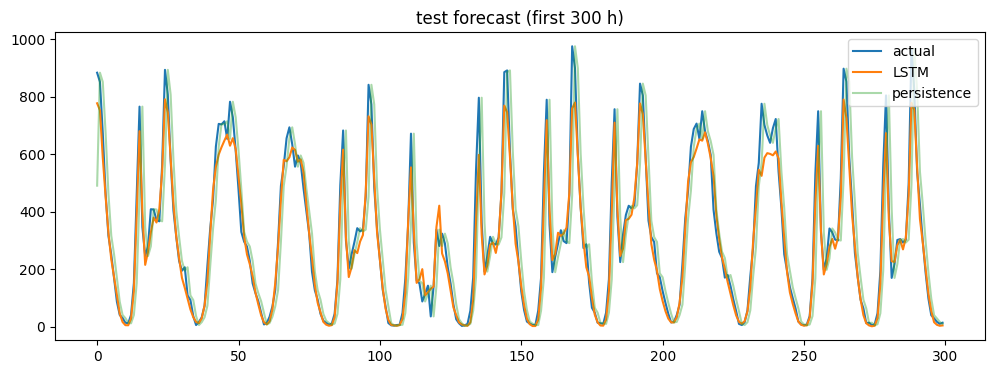

In [6]:
model.eval()
with torch.no_grad(): pte=model(torch.tensor(Xte).to(DEVICE)).cpu().numpy()*cnt_std+cnt_mean
def mae(a,b): return float(np.mean(np.abs(a-b)))
def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))
def mape(a,b): m=b>1; return float(np.mean(np.abs((a[m]-b[m])/b[m]))*100)
M={'model':{'MAE':mae(pte,yte_raw),'RMSE':rmse(pte,yte_raw),'MAPE':mape(pte,yte_raw)},
   'persistence':{'MAE':mae(persist_te,yte_raw),'RMSE':rmse(persist_te,yte_raw)},
   'seasonal_naive_24h':{'MAE':mae(season_te,yte_raw),'RMSE':rmse(season_te,yte_raw)}}
imp=100*(M['persistence']['MAE']-M['model']['MAE'])/M['persistence']['MAE']
print(json.dumps(M,indent=2)); print(f'improvement over persistence (MAE): {imp:.1f}%')
plt.figure(figsize=(12,4)); plt.plot(yte_raw[:300],label='actual'); plt.plot(pte[:300],label='LSTM'); plt.plot(persist_te[:300],label='persistence',alpha=.4); plt.legend(); plt.title('test forecast (first 300 h)'); plt.show()

In [7]:
os.makedirs('brain',exist_ok=True)
torch.save(model.state_dict(),'brain/demand_forecaster.pt')
pickle.dump(scaler,open('brain/scaler.pkl','wb'))
meta={**CFG,'scaler_mean':scaler.mean_.tolist(),'scaler_scale':scaler.scale_.tolist()}
json.dump(meta,open('brain/model_meta.json','w'),indent=2)
metrics={'mae':round(M['model']['MAE'],3),'rmse':round(M['model']['RMSE'],3),'mape':round(M['model']['MAPE'],3),
         'persistence_mae':round(M['persistence']['MAE'],3),'seasonal_naive_mae':round(M['seasonal_naive_24h']['MAE'],3),
         'improvement_over_persistence_pct':round(imp,2),'dataset':'UCI Bike Sharing #275 (chronological split, no leakage)','window':WINDOW}
json.dump(metrics,open('brain/metrics.json','w'),indent=2)
with zipfile.ZipFile('demand_brain.zip','w',zipfile.ZIP_DEFLATED) as zz:
    for fn in ['demand_forecaster.pt','scaler.pkl','model_meta.json','metrics.json']: zz.write('brain/'+fn,fn)
print('saved demand_brain.zip')
try:
    from google.colab import files; files.download('demand_brain.zip')
except Exception as e: print('grab demand_brain.zip from the file browser', e)

saved demand_brain.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
**Sanity:** the LSTM MAE must beat **persistence** (and ideally seasonal-naive) on the *latest* (test) period
— if it doesn't beat persistence, the model has no real value; tell me and I'll adjust before wiring.